In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
import module1 as m1

In [15]:
with np.load("/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/electron_test/electron_cubes_fixed1_new.npz") as data:
    stacked = data["stacked"]   # shape (12, 200, 2000, 20), complex128
    x_vals  = data["x_vals"]


hdu_c = fits.open('/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/constants/Constants1.fits')
nu =  hdu_c[0].header['nu']
mu = hdu_c[0].header['mu']
lam = hdu_c[0].header['lam']
GC = hdu_c[0].header['GC']
c = hdu_c[0].header['c']
tol = hdu_c[0].header['tol']
direcPhoton = hdu_c[0].header['P_direc']
direcElectron = hdu_c[0].header['E_direc']
alpha = hdu_c[0].header['alpha']

M = hdu_c[0].header['M']
T = hdu_c[0].header['Temp']
hdu_c.close()

ks=[-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,1,2,3,4,5,6,7,8,9,10]

In [3]:
print(mu/T)

1.0504609833919372


In [4]:
h_prime = np.linspace(0.01*T, 20*T, 2000)  # length = 2000
h_prime_index = np.rint(h_prime * 100 * (8*np.pi*M)).astype(int)


idx = np.arange(0, 1991, 10)

h_grid = h_prime[idx]
h_index_grid = h_prime_index[idx]

In [5]:
print(h_prime_index)
print(h_index_grid)

[   1    2    3 ... 1998 1999 2000]
[   1   11   21   31   41   51   61   71   81   91  101  111  121  131
  141  151  161  171  181  191  201  211  221  231  241  251  261  271
  281  291  301  311  321  331  341  351  361  371  381  391  401  411
  421  431  441  451  461  471  481  491  501  511  521  531  541  551
  561  571  581  591  601  611  621  631  641  651  661  671  681  691
  701  711  721  731  741  751  761  771  781  791  801  811  821  831
  841  851  861  871  881  891  901  911  921  931  941  951  961  971
  981  991 1001 1011 1021 1031 1041 1051 1061 1071 1081 1091 1101 1111
 1121 1131 1141 1151 1161 1171 1181 1191 1201 1211 1221 1231 1241 1251
 1261 1271 1281 1291 1301 1311 1321 1331 1341 1351 1361 1371 1381 1391
 1401 1411 1421 1431 1441 1451 1461 1471 1481 1491 1501 1511 1521 1531
 1541 1551 1561 1571 1581 1591 1601 1611 1621 1631 1641 1651 1661 1671
 1681 1691 1701 1711 1721 1731 1741 1751 1761 1771 1781 1791 1801 1811
 1821 1831 1841 1851 1861 1871 1881 1891 

In [6]:
Rk_h  = np.full((10, 200),  np.nan, dtype=complex)
Tk_h  = np.full((10, 200),  np.nan, dtype=complex)
Rk_hp = np.full((10, 2000), np.nan, dtype=complex)
Tk_hp = np.full((10, 2000), np.nan, dtype=complex)

Rmink_h  = np.full((10, 200),  np.nan, dtype=complex)
Tmink_h  = np.full((10, 200),  np.nan, dtype=complex)
Rmink_hp = np.full((10, 2000), np.nan, dtype=complex)
Tmink_hp = np.full((10, 2000), np.nan, dtype=complex)

In [7]:
for k in range(1, 11):
    file_path = f"{direcElectron}{k}ExtendedOmega.fits"
    with fits.open(file_path) as hdu:
        for j, h_idx in enumerate(h_index_grid):
            hdr = hdu[h_idx].header
            Rk_h[k-1, j] = hdr.get('R', np.nan)
            Tk_h[k-1, j] = hdr.get('T', np.nan)

        for j, hp_idx in enumerate(h_prime_index):
            hdr = hdu[hp_idx].header
            Rk_hp[k-1, j] = hdr.get('R', np.nan)
            Tk_hp[k-1, j] = hdr.get('T', np.nan)

for k in range(1, 11):
    file_path = f"{direcElectron}min{k}ExtendedOmega.fits"
    with fits.open(file_path) as hdu:
        for j, h_idx in enumerate(h_index_grid):
            hdr = hdu[h_idx].header
            Rmink_h[k-1, j] = hdr.get('R', np.nan)
            Tmink_h[k-1, j] = hdr.get('T', np.nan)

        for j, hp_idx in enumerate(h_prime_index):
            hdr = hdu[hp_idx].header
            Rmink_hp[k-1, j] = hdr.get('R', np.nan)
            Tmink_hp[k-1, j] = hdr.get('T', np.nan)

In [8]:
def FGsort(k,ksign,FGk,FGmink):
    if (k*ksign>0):
        return np.squeeze(FGk)
    else:
        return np.squeeze(FGmink)

def RTsort(k,RTk,RTmink):
    if (k>0):
        return np.array(RTk[k-1]).reshape(1).item()
    else:
        return np.array(RTmink[-k-1]).reshape(1).item()

In [9]:
def make_B1s():
    dh_prime = h_prime[1]-h_prime[0]
    array_B0s = np.zeros((2,20,200,2000))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j,i] = -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])+stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
                    array_B0s[1,k,j,i] = dh_prime*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[3,j,i,k]*np.conj(stacked[1,j,i,k])+stacked[7,j,i,k]*np.conj(stacked[5,j,i,k])))
    return (array_B0s)

In [10]:
def make_B0s():
    dh_prime = h_prime[1]-h_prime[0]
    array_B0s = np.zeros((2,20, 200))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j]+= -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])+stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
                    array_B0s[1,k,j]+= dh_prime*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[3,j,i,k]*np.conj(stacked[1,j,i,k])+stacked[7,j,i,k]*np.conj(stacked[5,j,i,k])))
    return (array_B0s)

In [11]:
def make_B0s_0():
    dh_prime = h_prime[1]-h_prime[0]
    array_B0s = np.zeros((2,20, 200))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j]+= -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])))
                    array_B0s[1,k,j]+= -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
    return (array_B0s)

In [12]:
def make_B0s_even():
    dh_prime = h_prime[1]-h_prime[0]
    dh_eff   = 2*dh_prime   # spacing doubles when you keep only even points
    array_B0s = np.zeros((2,20, 200))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                elif (hp_idx % 2 != 0):     # keep EVEN only
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j]+= -dh_eff*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])+stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
                    array_B0s[1,k,j]+= dh_eff*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[3,j,i,k]*np.conj(stacked[1,j,i,k])+stacked[7,j,i,k]*np.conj(stacked[5,j,i,k])))
    return (array_B0s)


def make_B0s_odd():
    dh_prime = h_prime[1]-h_prime[0]
    dh_eff   = 2*dh_prime   # spacing doubles when you keep only odd points
    array_B0s = np.zeros((2,20, 200))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                elif (hp_idx % 2 == 0):     # keep ODD only
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j]+= -dh_eff*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])+stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
                    array_B0s[1,k,j]+= dh_eff*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[3,j,i,k]*np.conj(stacked[1,j,i,k])+stacked[7,j,i,k]*np.conj(stacked[5,j,i,k])))
    return (array_B0s)


In [13]:
def make_B1s_0():
    dh_prime = h_prime[1]-h_prime[0]
    array_B0s = np.zeros((2,20,200,2000))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j,i] = -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[2,j,i,k]*np.conj(stacked[0,j,i,k])))
                    array_B0s[1,k,j,i] = -dh_prime*pre*fh*(fhp-fh)*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[6,j,i,k]*np.conj(stacked[4,j,i,k])))
    return (array_B0s)

In [14]:
def make_B0s_1():
    dh_prime = h_prime[1]-h_prime[0]
    array_B0s = np.zeros((2,20, 200))
    pre = alpha/M/(2*np.pi)
    for k in range(len(ks)):
        for j, h_idx in enumerate(h_index_grid):
            fh = 1/(np.exp(8*np.pi*M*h_grid[j])+1)
            for i, hp_idx in enumerate(h_prime_index):
                if (h_idx == hp_idx):
                    continue
                else:
                    fhp = 1/(np.exp(8*np.pi*M*h_prime[i])+1)
                    array_B0s[0,k,j]+= dh_prime*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[3,j,i,k]*np.conj(stacked[1,j,i,k])))
                    array_B0s[1,k,j]+= dh_prime*pre*fh*fh*np.imag(RTsort(ks[k],Rk_h[:,j],Rmink_h[:,j])*np.conj(RTsort(ks[k],Tk_h[:,j],Tmink_h[:,j]))*(stacked[7,j,i,k]*np.conj(stacked[5,j,i,k])))
    return (array_B0s)


In [15]:
B0 = make_B0s()

In [16]:
B0_even = make_B0s_even()

In [17]:
B0_odd = make_B0s_odd()

In [15]:
B00 = make_B0s_0()

In [16]:
B01 = make_B0s_1()

In [17]:
B1 = make_B1s()

In [18]:
B10 = make_B1s_0()

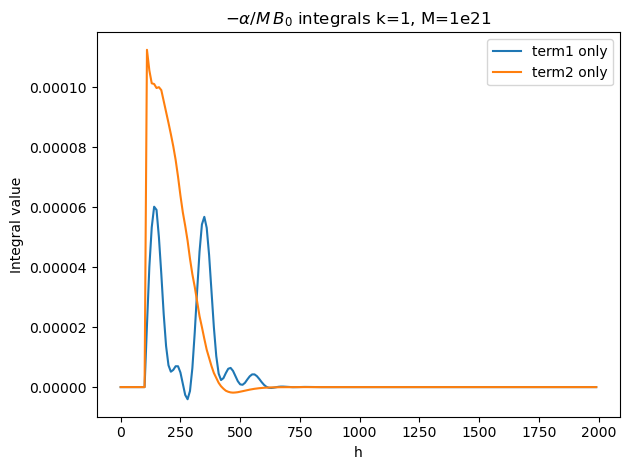

In [18]:
y = B0[:,10,:]
plt.plot(x_vals, y[0])
plt.plot(x_vals, y[1])
#plt.plot(x_vals, y[0]+y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['term1 only', 'term2 only','sum'])
#plt.yscale('log')
#plt.xlim(190,450)
plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrals k=1, M=1e21")
plt.tight_layout()
plt.show()

In [17]:
with np.load("/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/electron_test/B0_M1_new.npz") as data:
    B0 = data["B0"]   # shape (12, 200, 2000, 20), complex128

In [7]:
print(B0.shape)

(2, 20, 200)


In [8]:
Bs = np.zeros([2,200])
for k in range(len(ks)):
    j=(np.abs(ks[k]) - 1/2)
    Bs[0] += (2*j + 1) * b0[0, k].real
    Bs[1] += (2*j + 1) * b0[1, k].real

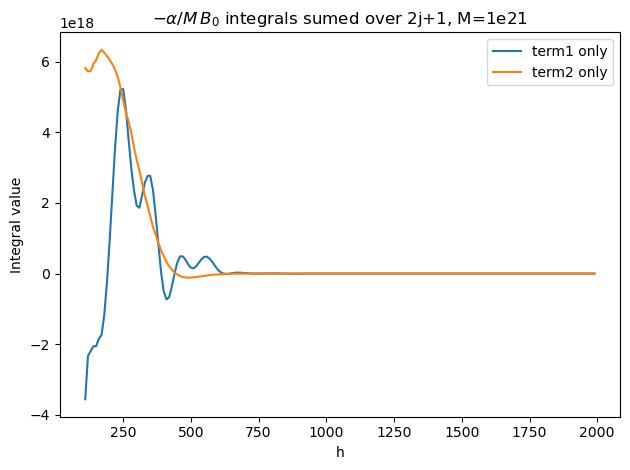

In [11]:
plt.plot(x_vals, Bs[0]*(8*np.pi*M))
plt.plot(x_vals, Bs[1]*(8*np.pi*M))
#plt.plot(x_vals, y[0]+y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['term1 only', 'term2 only','sum'])
#plt.yscale('log')
#plt.xlim(190,450)
plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrals sumed over 2j+1, M=1e21")
plt.tight_layout()
plt.show()

In [13]:
print(B0.shape)
outpath = "/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/electron_test/B0_M1_new.npz"
np.savez_compressed(outpath, B0=B0)

(2, 20, 200)


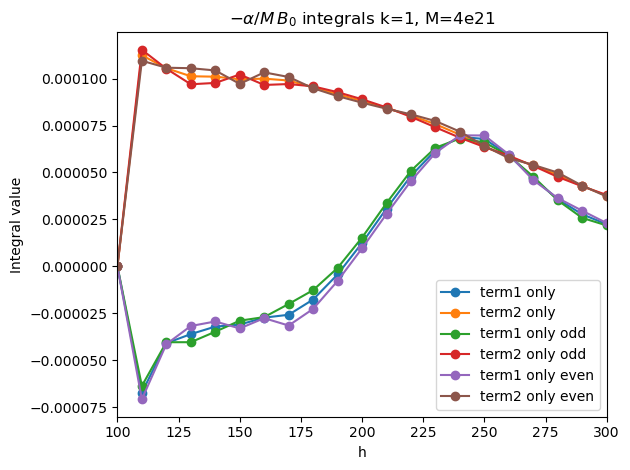

In [19]:
y = B0[:,10,:]
y1 = B0_odd[:,10,:]
y2 = B0_even[:,10,:]
plt.plot(x_vals, y[0],'-o')
plt.plot(x_vals, y[1],'-o')

plt.plot(x_vals, y1[0],'-o')
plt.plot(x_vals, y1[1],'-o')

plt.plot(x_vals, y2[0],'-o')
plt.plot(x_vals, y2[1],'-o')

#plt.plot(x_vals, y[0]+y[1])
plt.legend(['term1 only', 'term2 only','term1 only odd', 'term2 only odd','term1 only even', 'term2 only even'])
#plt.yscale('log')
plt.xlim(100,300)
plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrals k=1, M=4e21")
plt.tight_layout()
plt.show()

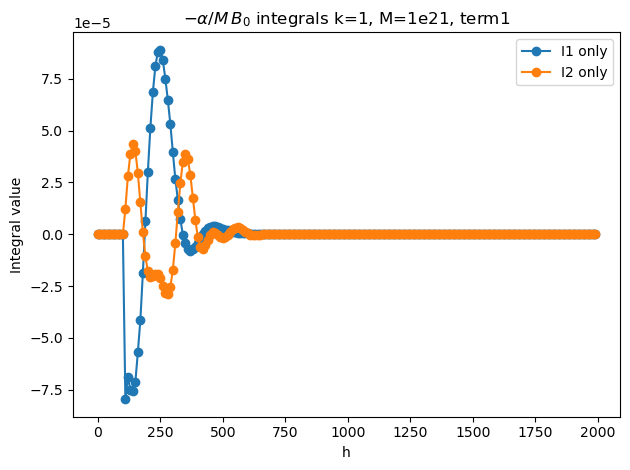

In [20]:
y = B00[:,10,:]
plt.plot(x_vals, y[0],'-o')
plt.plot(x_vals, y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['I1 only', 'I2 only','sum'])
#plt.yscale('log')
#plt.xlim(190,450)
plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrals k=1, M=1e21, term1")
plt.tight_layout()
plt.show()

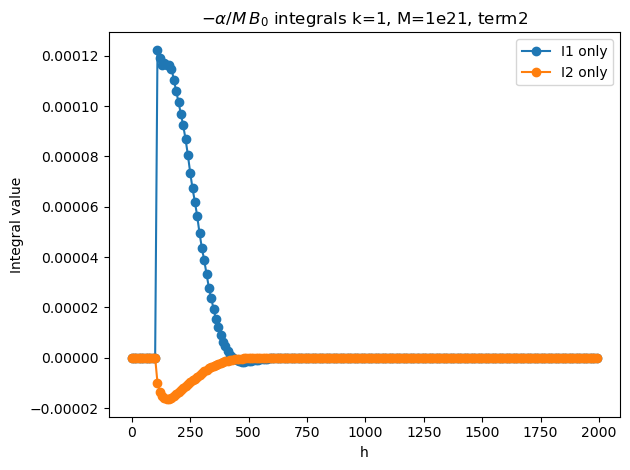

In [21]:
y = B01[:,10,:]
plt.plot(x_vals, y[0],'-o')
plt.plot(x_vals, y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['I1 only', 'I2 only','sum'])
#plt.yscale('log')
#plt.xlim(190,450)
plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrals k=1, M=1e21, term2")
plt.tight_layout()
plt.show()

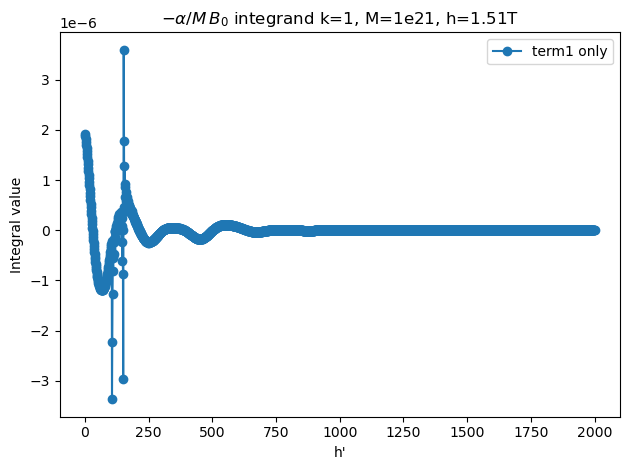

In [22]:
y = B1[:,10,15]
plt.plot(h_prime_index, y[0],'-o')
#plt.plot(h_prime_index, y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['term1 only', 'term2 only','sum'])
#plt.yscale('log')
#plt.xlim(190,450)
plt.xlabel("h'")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrand k=1, M=1e21, h=1.51T")
plt.tight_layout()
plt.show()

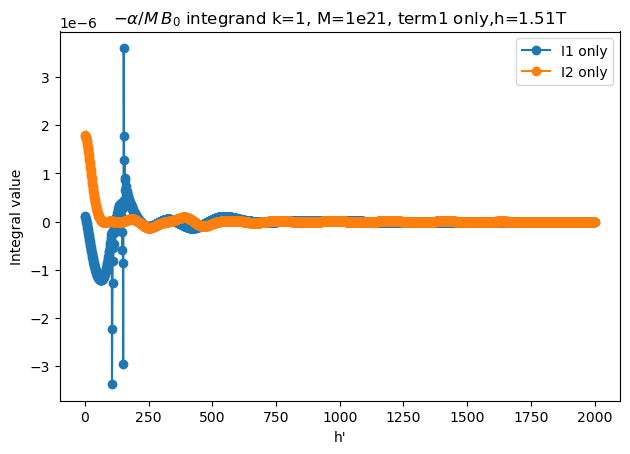

In [25]:
y = B10[:,10,15]
plt.plot(h_prime_index, y[0],'-o')
plt.plot(h_prime_index, y[1],'-o')
#plt.plot(x_vals, y[0]+y[1])
plt.legend(['I1 only', 'I2 only','sum'])
#plt.yscale('log')
#plt.xlim(100,160)
plt.xlabel("h'")
plt.ylabel("Integral value")
plt.title(r"$-\alpha/M\, B_0$ integrand k=1, M=1e21, term1 only,h=1.51T")
plt.tight_layout()
plt.show()

In [9]:
with np.load("/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/electron_test/electron_cubes_fixed.npz") as data:
    stacked = data["stacked"] 

In [10]:
with np.load("/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/electron_test/electron_cubes_fixed1_new.npz") as data:
    stacked_new = data["stacked"] 

In [18]:
print(stacked[0,50,:,11])

[ 1.79180671e+21+2.84643532e+21j  1.74100074e+21+2.96045292e+21j
  1.68538946e+21+3.07412707e+21j ... -4.39276274e+18-4.67412334e+19j
 -4.14550422e+18-4.66323698e+19j -4.44042369e+18-4.61983994e+19j]


In [19]:
print(stacked_new[0,50,:,11])

[-1.42232056e+20-2.18976731e+20j -1.43118079e+20-2.18707771e+20j
 -1.44000053e+20-2.18429424e+20j ... -5.19770811e+18-4.66655823e+19j
 -5.36758048e+18-4.66961409e+19j -5.52469827e+18-4.67048361e+19j]


In [11]:
import numpy as np
import matplotlib.pyplot as plt

with np.load(
    "/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/"
    "electron_test/B0_M1_new.npz"
) as data:
    b0 = data["B0"]

print("b0 shape:", b0.shape)   # expected: (2, 20, 200)

ks = np.array([
    -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,
      1,  2,  3,  4,  5,  6,  7,  8,  9, 10
])

# First index:
# 0 = first B0 term
# 1 = second B0 term
Bs_low = np.zeros((2, 200))
Bs_high = np.zeros((2, 200))

for k_index, kappa in enumerate(ks):

    j = abs(kappa) - 0.5
    degeneracy = 2*j + 1       # equal to 2*abs(kappa)

    if abs(kappa) <= 5:
        Bs_low[0] += degeneracy * b0[0, k_index].real
        Bs_low[1] += degeneracy * b0[1, k_index].real

    else:
        Bs_high[0] += degeneracy * b0[0, k_index].real
        Bs_high[1] += degeneracy * b0[1, k_index].real

b0 shape: (2, 20, 200)


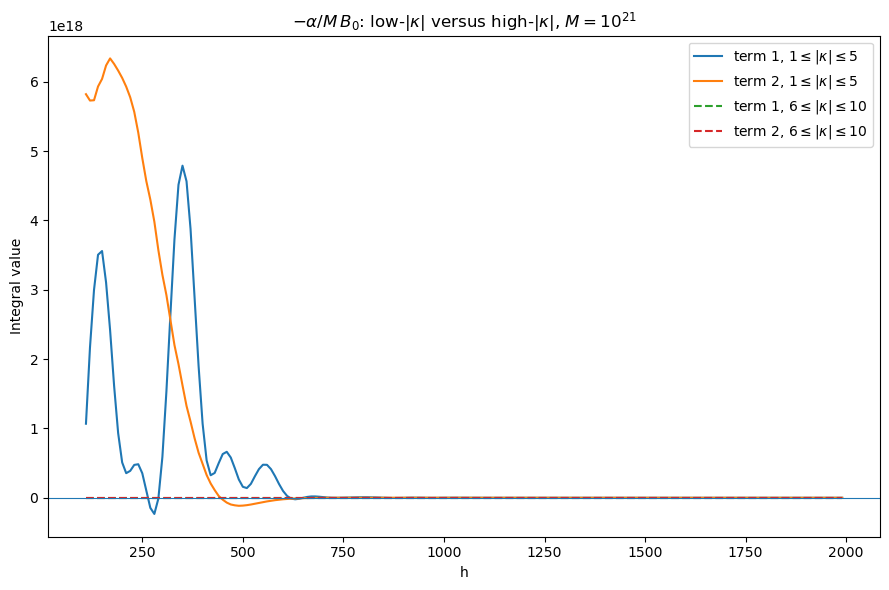

In [16]:
scale = 8*np.pi*M

plt.figure(figsize=(9, 6))

plt.plot(
    x_vals,
    Bs_low[0] * scale,
    label=r"term 1, $1\leq|\kappa|\leq5$"
)

plt.plot(
    x_vals,
    Bs_low[1] * scale,
    label=r"term 2, $1\leq|\kappa|\leq5$"
)

plt.plot(
    x_vals,
    Bs_high[0] * scale,
    linestyle="--",
    label=r"term 1, $6\leq|\kappa|\leq10$"
)

plt.plot(
    x_vals,
    Bs_high[1] * scale,
    linestyle="--",
    label=r"term 2, $6\leq|\kappa|\leq10$"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("h")
plt.ylabel("Integral value")
plt.title(
    r"$-\alpha/M\,B_0$: low-$|\kappa|$ versus high-$|\kappa|$, "
    r"$M=10^{21}$"
)

plt.legend()
plt.tight_layout()
plt.show()

b0 shape: (2, 20, 200)


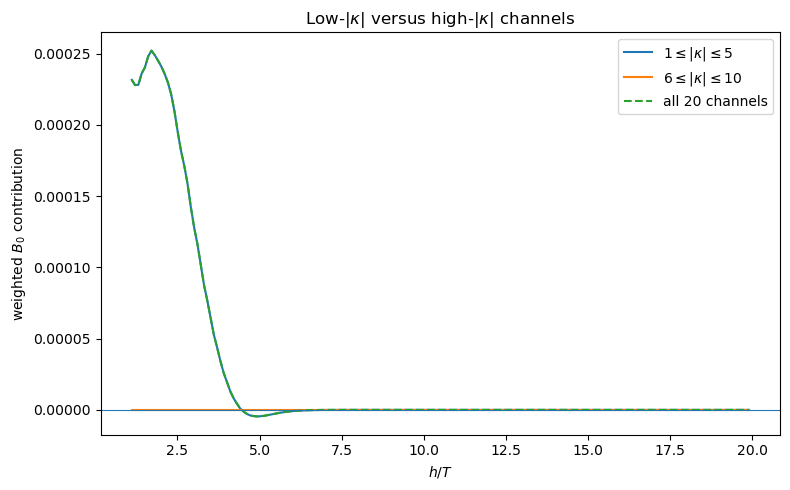

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load B0
# ------------------------------------------------------------
path = (
    "/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/"
    "electron_test/B0_M1_new.npz"
)

with np.load(path) as data:
    b0 = data["B0"]

print("b0 shape:", b0.shape)

# κ ordering used when B0 was created
ks = np.array([
    -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,
      1,  2,  3,  4,  5,  6,  7,  8,  9, 10
])

if b0.shape != (2, 20, 200):
    raise ValueError(f"Unexpected B0 shape: {b0.shape}")

# Physical external-energy grid: h/T = 0.01, 0.11, ..., 19.91
h_over_T = np.arange(1, 1992, 10) / 100.0

# ------------------------------------------------------------
# Sum the two B0 terms for every κ
# Result shape: (20, 200)
# ------------------------------------------------------------
b0_per_k = np.real(b0[1])

# Degeneracy: 2j+1 = 2|κ|
degeneracy = 2.0 * np.abs(ks)

b0_per_k_weighted = degeneracy[:, None] * b0_per_k

# ------------------------------------------------------------
# Divide into low-|κ| and high-|κ| groups
# There is no κ=0.
# ------------------------------------------------------------
low_mask = np.abs(ks) <= 5
high_mask = np.abs(ks) > 5

b0_low = np.sum(b0_per_k_weighted[low_mask], axis=0)
b0_high = np.sum(b0_per_k_weighted[high_mask], axis=0)
b0_total = b0_low + b0_high

# ------------------------------------------------------------
# Plot the comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(h_over_T, b0_low, label=r"$1\leq |\kappa|\leq 5$")
plt.plot(h_over_T, b0_high, label=r"$6\leq |\kappa|\leq 10$")
plt.plot(h_over_T, b0_total, linestyle="--", label="all 20 channels")

plt.axhline(0.0, linewidth=0.8)
plt.xlabel(r"$h/T$")
plt.ylabel(r"weighted $B_0$ contribution")
plt.title(r"Low-$|\kappa|$ versus high-$|\kappa|$ channels")
plt.legend()
plt.tight_layout()
plt.show()

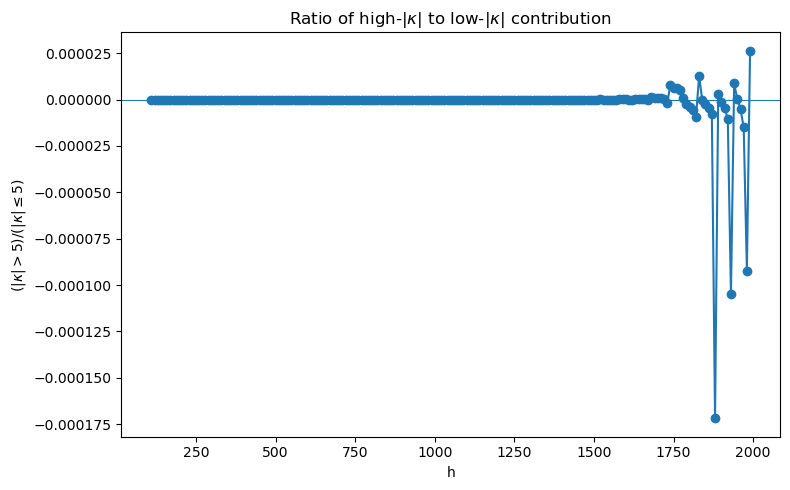

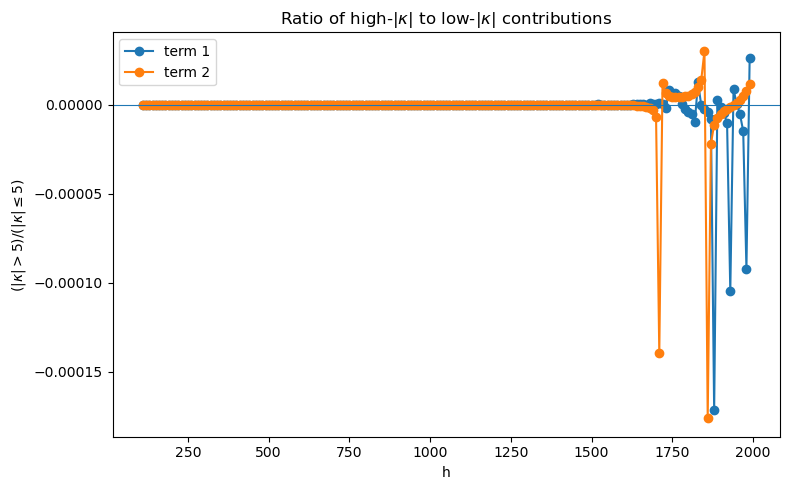

In [24]:
import numpy as np
import matplotlib.pyplot as plt

with np.load(
    "/users/PCON0003/bowenchen12686/ondemand/data/sys/myjobs/"
    "electron_test/B0_M1_new.npz"
) as data:
    b0 = data["B0"]

ks = np.array([
    -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,
      1,  2,  3,  4,  5,  6,  7,  8,  9, 10
])

# if x_vals is not already in memory, reconstruct the same grid used in notebook
x_vals = np.arange(0, 1991, 10)

# summed over (2j+1) separately for the two terms
Bs_low = np.zeros((2, 200))
Bs_high = np.zeros((2, 200))

for k_index, kappa in enumerate(ks):
    weight = 2 * abs(kappa)   # 2j+1

    if abs(kappa) <= 5:
        Bs_low[0] += weight * b0[0, k_index].real
        Bs_low[1] += weight * b0[1, k_index].real
    else:
        Bs_high[0] += weight * b0[0, k_index].real
        Bs_high[1] += weight * b0[1, k_index].real

# ratios for the two terms separately
ratio_term1 = np.divide(
    Bs_high[0],
    Bs_low[0],
    out=np.full_like(Bs_high[0], np.nan),
    where=np.abs(Bs_low[0]) > 1e-30
)

ratio_term2 = np.divide(
    Bs_high[1],
    Bs_low[1],
    out=np.full_like(Bs_high[1], np.nan),
    where=np.abs(Bs_low[1]) > 1e-30
)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, ratio_term1, '-o', label='term 1')
plt.plot(x_vals, ratio_term2, '-o', label='term 2')
plt.axhline(0, linewidth=0.8)
plt.xlabel("h")
plt.ylabel(r"$(|\kappa|>5)/(|\kappa|\leq5)$")
plt.title(r"Ratio of high-$|\kappa|$ to low-$|\kappa|$ contributions")
plt.legend()
plt.tight_layout()
plt.show()